# BaTiO₃(001) surface — termination-resolved spectral function

A perovskite (001) surface can terminate on **two distinct planes** — the **BaO** plane or the **TiO₂** plane. `analysis.surface` selects between them by grouping the Wannier functions into **sublayers by height along the surface normal** (`wf_sublayers`) and cutting the semi-infinite stack just above the chosen sublayer (`termination=`). The downfolded bulk is identical for both; only the exposed layer changes.

Beyond the O 2$p$ valence manifold of `w90tutorial/09_batio3_bulk`, this notebook also Wannierises the **Ti $t_{2g}$ conduction triplet** ($d_{xz},d_{yz},d_{xy}$, the lowest conduction manifold of a $d^0$ cubic perovskite, crystal-field-split below $e_g$) — 12 MLWFs total, genuinely **disentangled** this time (the $t_{2g}$ bands hybridize with higher conduction bands away from $\Gamma$) rather than the isolated-band case notebook 09 uses. The $t_{2g}$ orbitals sit at the Ti site, which is in the **same** atomic plane as the TiO$_2$-plane oxygens, so switching to the TiO$_2$ termination exposes the conduction character at the surface too.

Self-contained: runs its own converged DFT, no precomputed fixture.

### 1. Structure, converged DFT, and the sublayers
Cubic perovskite, $a = 7.44266$ bohr. 9 O-2$p$ orbitals (analytic `O:p` projections, one triplet per oxygen) plus the Ti $t_{2g}$ triplet (analytic $d_{xz}/d_{yz}/d_{xy}$ projections at the Ti site) -- `frozen_window` pins the O-2$p$ valence manifold exactly, `outer_window` extends just past the $t_{2g}$ bands (leaving out the next, higher conduction manifold) so disentanglement has just enough room to extract a clean $t_{2g}$ triplet.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV, EV_TO_HARTREE
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not notebooks/-specific
NCORES = 16
waw.set_num_threads(NCORES)
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


In [2]:
from ase import Atoms
from waw.interfaces.ase.structure import real_lattice
from waw.interfaces.projections import spd_projections
from waw.analysis.surface import wf_sublayers, surface_spectral_function

a = 7.44266 * BOHR_TO_ANG
frac = [[0, 0, 0], [0.5, 0.5, 0.5], [0, 0.5, 0.5], [0.5, 0.5, 0], [0.5, 0, 0.5]]
atoms = Atoms('BaTiO3', scaled_positions=frac,
              cell=[[a, 0, 0], [0, a, 0], [0, 0, a]], pbc=True)
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'batio3'

o_sites = [(0, 0.5, 0.5), (0.5, 0.5, 0), (0.5, 0, 0.5)]
projections = [p for o in o_sites for p in spd_projections(o, 'p')]
t2g_mr = (2, 3, 5)   # wannier90 mr order for l=2: dz2,dxz,dyz,dx2-y2,dxy
projections += [((0.5, 0.5, 0.5), 2, mr, 1, (0., 0., 1.), (1., 0., 0.), 1.0)
                for mr in t2g_mr]

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'batio3',
    ecutwfc=60, scf_kpts=(8, 8, 8), nbnd=26, num_wann=12,
    exclude_bands=list(range(1, 12)),   # Ba/Ti/O semicore + O-2s
    projections=projections,
    pseudopotentials={'Ba': 'Ba.upf', 'Ti': 'Ti.upf', 'O': 'O.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,          # reuse a completed SCF in runs/batio3/ if present
)
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=12,
    frozen_window=(-1e3, 12.0), outer_window=(-1e3, 16.0),
    n_restarts=3, dis_n_iter=1000, n_iter=3000, verbose=False,
)
real_lattice_ = real_lattice(atoms)
E_FERMI = ov['fermi_energy']
print(f'Omega_I = {result.dis.omega_i * BOHR_TO_ANG**2:.4f} Ang^2')
print(f'Omega_total = {result.omega_final * BOHR_TO_ANG**2:.4f} Ang^2')
print(f'E_F = {E_FERMI:.3f} eV')

miller = (0, 0, 1)
frac_z, heights = wf_sublayers(real_lattice_, miller, result.centres_bohr)
print('sublayer heights (frac along normal):', np.round(heights, 3))
print('-> termination 0 = BaO-plane exposed (3 O-2p WFs);')
print('   termination 1 = TiO2-plane exposed (6 O-2p + 3 Ti-t2g WFs)')

/tmp/ipykernel_2571102/2775924999.py:19: RuntimeWarning: reusing the overlaps in /aims_data/miguel/nas-data001/claude/wannier/workflows/notebooks/runs/batio3 but batio3.waw-provenance.json is absent, so it cannot be checked that they were made with the settings passed now. If `projections`, `num_wann`, `exclude_bands` or the scdm/atom_proj settings have changed since they were written, the reused .amn is stale and the resulting model is built on the old projections. Delete /aims_data/miguel/nas-data001/claude/wannier/workflows/notebooks/runs/batio3/*.amn (or pass rerun_nscf=True) if in doubt; from now on this is detected automatically.
  ov = qe.generate_overlaps(


Omega_I = 13.7310 Ang^2
Omega_total = 14.0209 Ang^2
E_F = 11.109 eV


sublayer heights (frac along normal): [0.  0.5]
-> termination 0 = BaO-plane exposed (3 O-2p WFs);
   termination 1 = TiO2-plane exposed (6 O-2p + 3 Ti-t2g WFs)


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the deviation printed on the
Wannierization mesh is the quantitative form of the same statement.

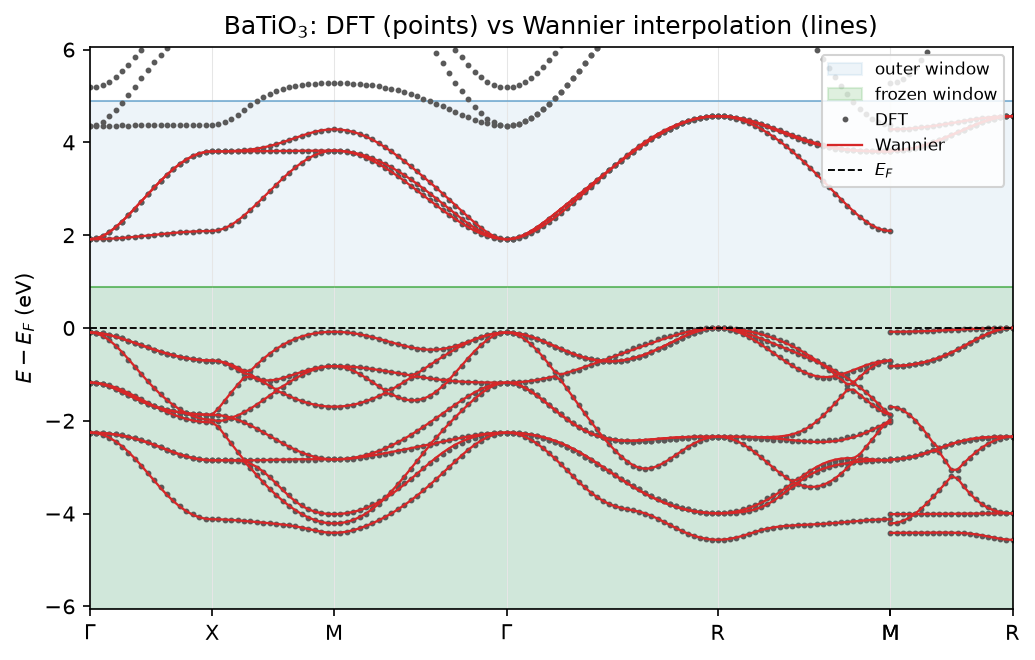

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 576 states


In [3]:
from waw.interfaces.ase.structure import band_path
from waw.analysis.elph import band_eigensystem
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = E_FERMI
bp = band_path(atoms, npoints=150)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = band_eigensystem(result.hr, bp.kpts)[0] * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'batio3', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(-1e3, 16.0), frozen_window=(-1e3, 12.0), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('BaTiO$_3$: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(-1e3, 12.0), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


### 2. Two terminations of the (001) surface
Same square surface BZ path Γ̄–X̄–M̄–Γ̄; only the exposed sublayer differs. The energy window now spans the full O-2$p$ valence manifold **and** the $t_{2g}$ conduction bands above the gap.

In [4]:
def seg(a, b, n): return np.linspace(a, b, n, endpoint=False)
G, X, M = np.array([0, 0.]), np.array([0.5, 0]), np.array([0.5, 0.5])
NSEG = 80
kpath = np.vstack([seg(G, X, NSEG), seg(X, M, NSEG), seg(M, G, NSEG), [G]])
ticks = [0, NSEG, 2 * NSEG, 3 * NSEG]
energies = np.linspace(5.0, 17.0, 220) * EV_TO_HARTREE   # O-2p valence + Ti-t2g conduction

sfs = {t: surface_spectral_function(result.hr, real_lattice_, miller, kpath,
           energies, eta=0.05 * EV_TO_HARTREE, hr_cutoff=1e-6,
           termination=t, wf_centres=result.centres_bohr) for t in (0, 1)}
print('max |A_surf(term0) - A_surf(term1)| =',
      round(float(np.abs(sfs[0].A_surface - sfs[1].A_surface).max()), 2))

max |A_surf(term0) - A_surf(term1)| = 253.28


### 3. BaO- vs TiO₂-termination, and their difference

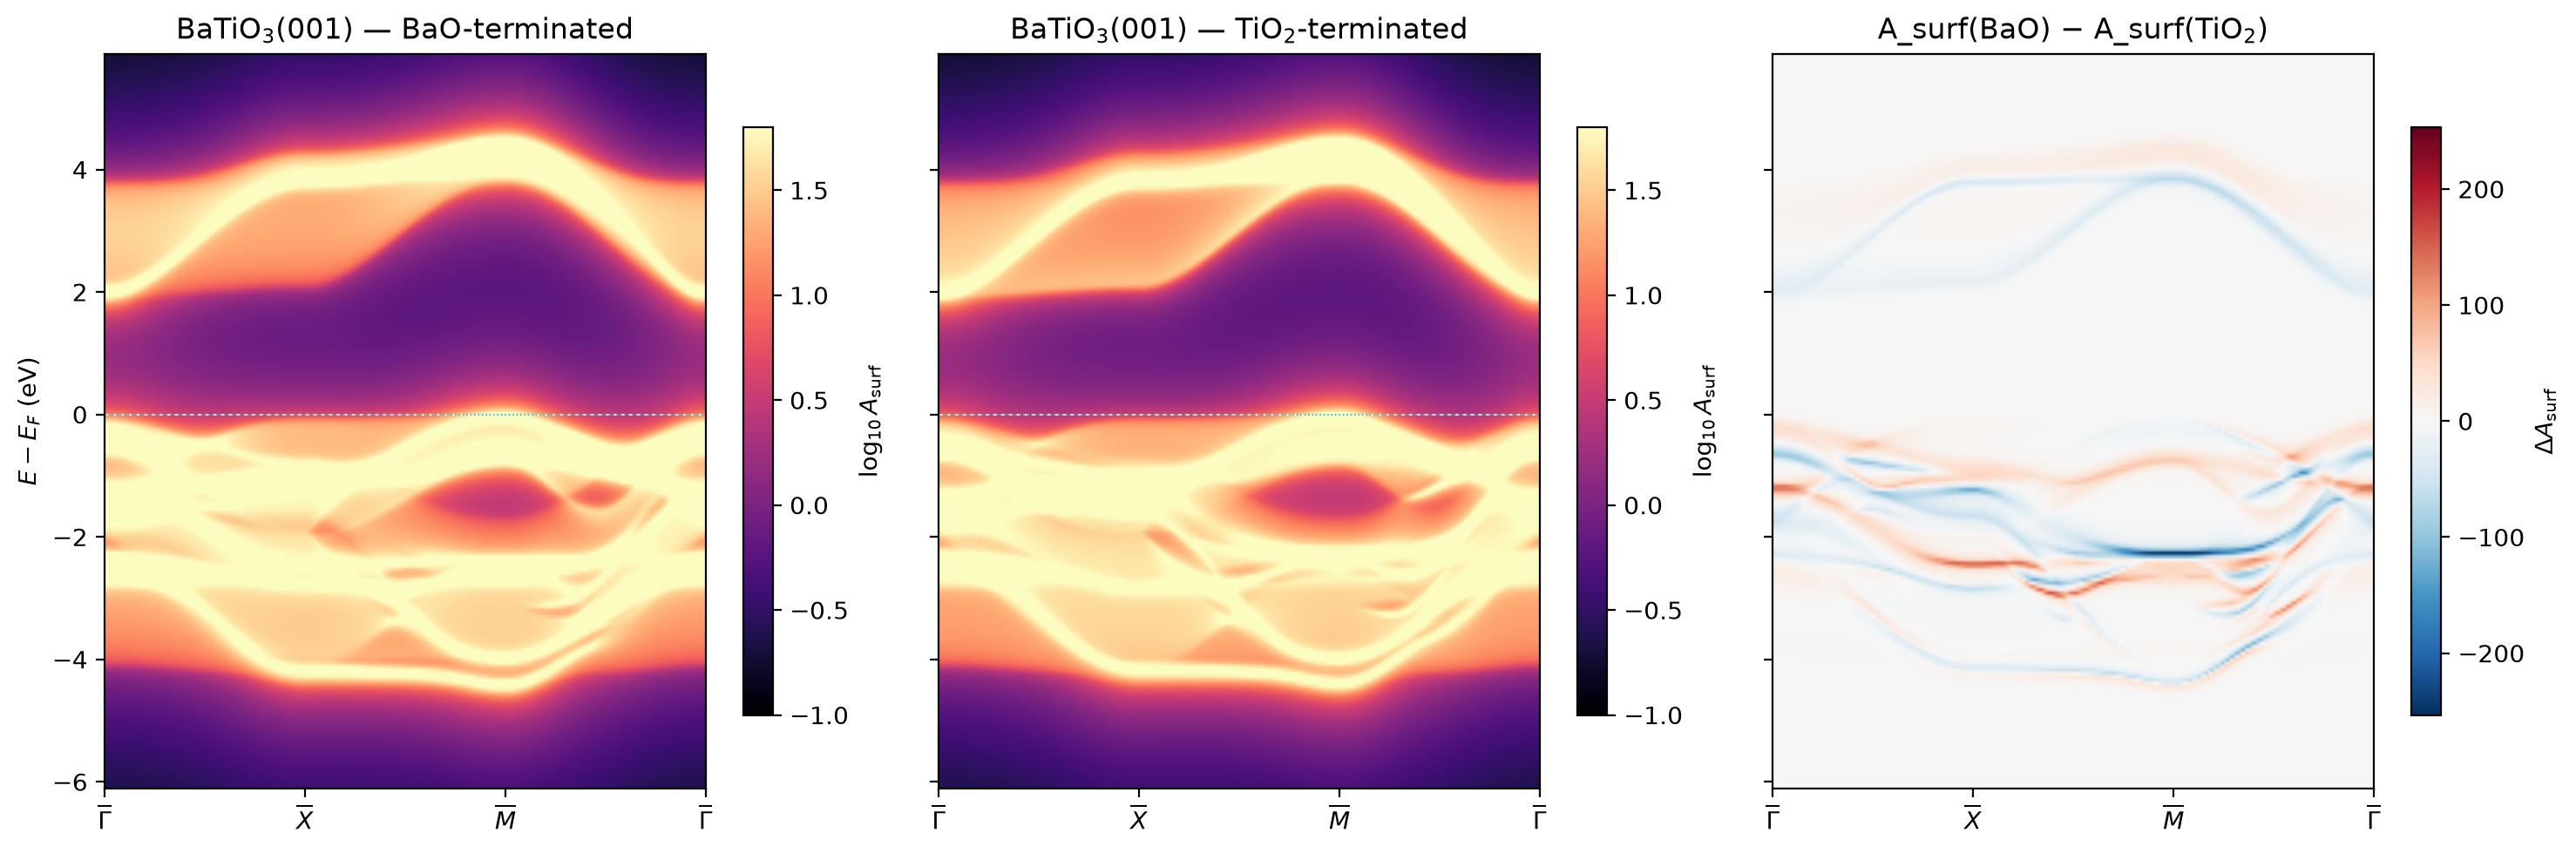

In [5]:
E = energies / EV_TO_HARTREE - E_FERMI
ext = [0, len(kpath) - 1, E[0], E[-1]]
lab = [r'$\overline{\Gamma}$', r'$\overline{X}$', r'$\overline{M}$', r'$\overline{\Gamma}$']
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, dpi=200)
for a, t, name in [(ax[0], 0, 'BaO-terminated'), (ax[1], 1, 'TiO$_2$-terminated')]:
    im = a.imshow(np.log10(sfs[t].A_surface.T + 1e-3), origin='lower', aspect='auto',
                  extent=ext, cmap='magma', vmin=-1, vmax=1.8, interpolation='bilinear')
    a.set_title('BaTiO$_3$(001) — ' + name)
    a.axhline(11.11 - E_FERMI, color='w', lw=0.6, ls='--')   # bulk O-2p/Ti-t2g gap edge
    a.axhline(0.0, color='c', lw=0.6, ls=':')                # E_F
    a.set_xticks(ticks); a.set_xticklabels(lab)
    fig.colorbar(im, ax=a, shrink=0.8, label=r'$\log_{10}A_\mathrm{surf}$')
d = sfs[0].A_surface - sfs[1].A_surface
im = ax[2].imshow(d.T, origin='lower', aspect='auto', extent=ext, cmap='RdBu_r',
                  vmin=-np.abs(d).max(), vmax=np.abs(d).max(), interpolation='bilinear')
ax[2].set_title('A_surf(BaO) − A_surf(TiO$_2$)')
ax[2].set_xticks(ticks); ax[2].set_xticklabels(lab)
fig.colorbar(im, ax=ax[2], shrink=0.8, label=r'$\Delta A_\mathrm{surf}$')
ax[0].set_ylabel(r'$E - E_F$ (eV)'); fig.tight_layout()

Both terminations share the same bulk-projected continuum below **and** above the gap — the downfolded bulk is termination-independent by construction — while exposing **different sharp surface-localized bands**, which the difference panel isolates.

The termination dependence is overwhelmingly a **valence** effect: it peaks in the O-2$p$ manifold immediately below the gap edge, at $\max|\Delta A_\mathrm{surf}| = 253$, against $69$ anywhere above it. So the two exposed planes reorganise the O-2$p$ surface bands strongly and the $t_{2g}$ ones only mildly — a factor 3.6.

That the conduction side responds **at all** is a consequence of where the Ti sits: the $t_{2g}$ orbitals are in the TiO$_2$ plane, so the two terminations present a genuinely different local environment above the gap and not only below it. A BaO-terminated surface has no Ti in its outermost plane, and its $t_{2g}$ weight is correspondingly whatever leaks up from the layer beneath.